# **Intro to Modeling**

<!DOCTYPE html><html><head><meta charset="utf-8"><title>data_science_pipeline.png</title></head><body>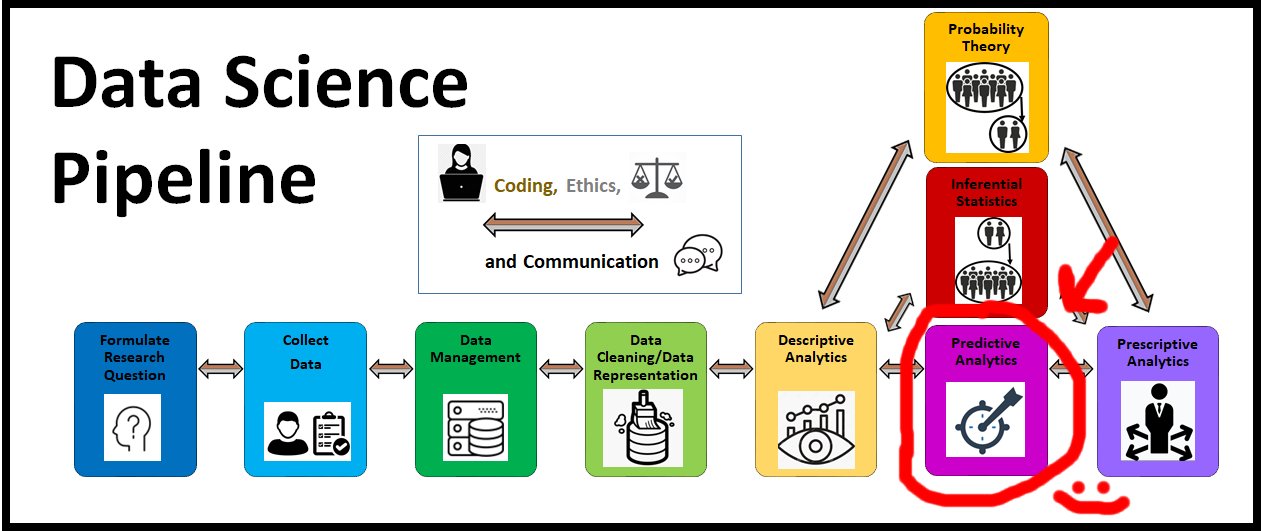</body></html>

In this notebook, we'll learn how to use **linear regression** to predict a continuous value.

We'll cover:
1. The intuition behind linear regression
2. Training vs. testing data
3. Fitting a model with `scikit-learn`
4. Making and visualizing predictions
5. Evaluating a regression model
6. Using multiple features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## What is Linear Regression?

Linear regression is a **supervised learning** algorithm used to predict a continuous numerical value.

For example:
- House prices
- Temperature
- Sales
- Salary

With one feature, linear regression tries to fit the best straight line through the data:

$$
\hat{y} = b_0 + b_1x
$$

where:

- $x$ = input feature
- $\hat{y}$ = predicted value
- $b_0$ = intercept
- $b_1$ = slope / coefficient

### How does the model decide which line is "best"?

Each prediction has some error:

$$
\text{error} = y - \hat{y}
$$

Linear regression chooses the line that minimizes the **sum of squared errors**.

A common way to measure this is Mean Squared Error:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2
$$

## California Housing Dataset

We'll use the California Housing dataset from `scikit-learn`.

Each row represents a California housing district. The dataset includes information such as median income, average number of rooms, population, and location.

Our goal is to predict the district's **median house value**.

In [49]:
# import dataset
housing = pd.read_csv("california_housing.csv")

In [50]:
print("Number of observations:", housing.shape[0])
print("Number of columns:", housing.shape[1])

Number of observations: 20640
Number of columns: 9


Before modeling, we typically want to split our dataframe into two; 
* $X$, which contains all of our explanatory variables
* $y$, which contains our response.

In [51]:
X = housing.drop(columns=["MedHouseVal"])
y = housing["MedHouseVal"]

## Simple Linear Regression

Let's start with only one feature: **median income (`MedInc`)**.

Our model will try to learn:

$$
\widehat{\text{HouseValue}} = b_0 + b_1(\text{MedInc})
$$

Using only one feature lets us visualize exactly what the model is doing.

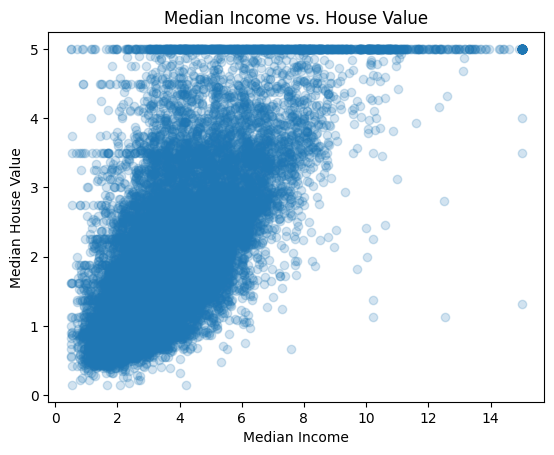

In [52]:
# select only the feature MedInc (KEEP AS MATRIX)
X_single = X[["MedInc"]]
plt.scatter(X_single["MedInc"], y, alpha=0.2)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs. House Value")

plt.show()

Even before fitting a model, we can see a positive relationship: districts with higher median income tend to have higher house values.

Linear regression will try to summarize this relationship with a straight line.

### Features vs. Target

In machine learning:

- `X` contains the information we give the model
- `y` contains the value we want the model to predict

For our simple regression:

- `X_single = MedInc`
- `y = Median House Value`

## Training and Testing Data

If we evaluate the model using the same data it trained on, we don't know how well it performs on new data.

So we split the dataset:

- **Training set:** used to learn the model
- **Test set:** used to evaluate the model

We'll use 80% for training and 20% for testing.

In [53]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_single,
    y,
    test_size=0.2,
    random_state=192
)
print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 16512
Testing examples: 4128


## Creating the Model

First, we'll create a linear regression model.

In [54]:
# instantiate a linear regression model
model = LinearRegression()

At this point, the model hasn't learned anything yet.

Calling `.fit()` uses the training data to learn the best intercept and slope.

In [55]:
# fit the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### What did the model learn?

The model has now learned the intercept and slope of the regression line.

In [56]:
# print out intercept and slope
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 0.4447110600879536
Slope: 0.4198171071716382


The slope tells us how much the model's predicted house value changes when median income increases by one unit.

Because the slope is positive, the model predicts higher house values as median income increases.

**This describes an association in the data, not necessarily a causal relationship.**

## Math behind predicting a value

Before using `.predict()`, let's use the regression equation directly.

Suppose a district has a median income value of 5.

In [57]:
income = 5

# plug 5 into linear regression equation
predicted_value = model.intercept_ + model.coef_[0] * income
predicted_value

np.float64(2.543796595946145)

This is exactly what `model.predict()` does for us automatically.

Let's now make predictions for every observation in the test set.

In [58]:
# predict for X_test
y_pred = model.predict(X_test)
y_pred

array([2.70357899, 1.97091417, 1.93598539, ..., 1.69505235, 2.75370515,
       3.72986389], shape=(4128,))

## Visualizing the Regression Line

Now that we have predictions, we can compare our fitted regression line to the actual test data.

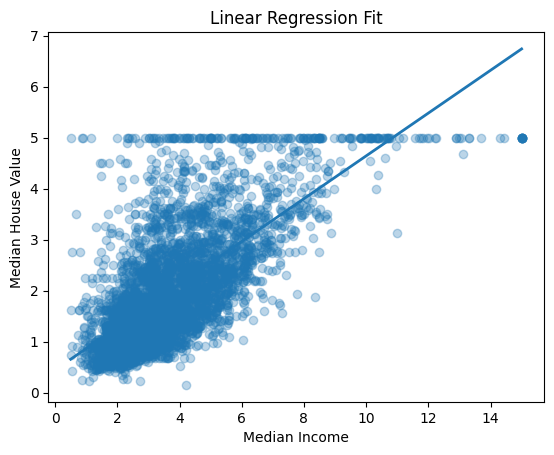

In [59]:
plt.scatter(X_test["MedInc"], y_test, alpha=0.3)

sorted_indices = np.argsort(X_test["MedInc"])

plt.plot(
    X_test["MedInc"].iloc[sorted_indices],
    y_pred[sorted_indices],
    linewidth=2
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression Fit")

plt.show()

## Evaluating the Model

Now that we've visualized our predictions, we need a numerical way to measure how well the model is performing.

### Mean Squared Error

MSE measures the average squared difference between our predictions and the actual values.

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Smaller values indicate smaller prediction errors.

In [60]:
# get mse and rmse

mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 0.7081599648536557
RMSE: 0.8415224090026693


RMSE is the square root of MSE.

Unlike MSE, RMSE is measured in the same units as the target, which makes it easier to interpret.

### $R^2$

$R^2$ (aka the coefficient of determination) measures how much variation in the target is explained by the model.

- $R^2 = 1$: perfect predictions
- $R^2 = 0$: no better than always predicting the mean
- Higher values generally indicate a better fit

In [61]:
# get r2
r2 = r2_score(y_true=y_test, y_pred=y_pred)

print("R²:", r2)

R²: 0.460653029038692


## Looking at Residuals

A residual is:

$$
\text{residual} = y - \hat{y}
$$

Residuals tell us how far each prediction was from the actual value.

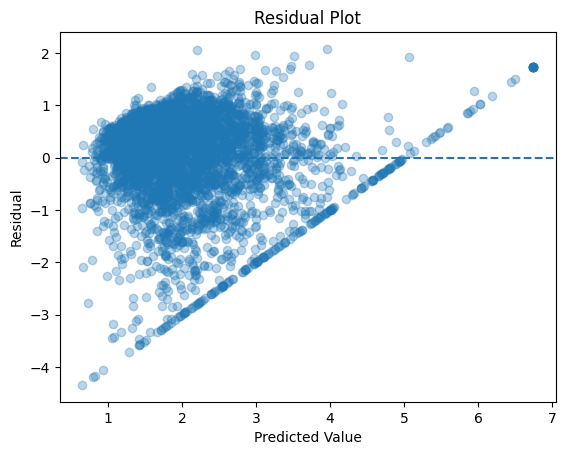

In [62]:
# get residuals
residuals = y_pred - y_test

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

# Multiple Linear Regression

So far, we've predicted house value using only median income.

But the dataset contains several features.

Multiple linear regression uses several features at once:

$$
\hat{y} = b_0 + b_1x_1 + b_2x_2 + \cdots + b_px_p
$$

In [63]:
X_multi = X
# get train-test split (again)
X_multi_train, X_multi_test, y_train, y_test = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=107
)

In [64]:
# instantiate linear regression model
multi_model = LinearRegression()

In [65]:
# fit model
multi_model.fit(X_multi_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
# predict with our new model
y_pred_multi = multi_model.predict(X_multi_test)

## Did Adding More Features Help?

We'll compare the multiple linear regression model to our original simple regression model using RMSE and $R^2$.

In [68]:
# secret import?
from sklearn.metrics import root_mean_squared_error

# get rmse using new function ad r2
multi_rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred_multi)
multi_r2 = r2_score(y_true=y_test, y_pred=y_pred_multi)

print("Simple Linear Regression")
print("RMSE:", rmse)
print("R²:", r2)

print("\nMultiple Linear Regression")
print("RMSE:", multi_rmse)
print("R²:", multi_r2)

Simple Linear Regression
RMSE: 0.8415224090026693
R²: 0.460653029038692

Multiple Linear Regression
RMSE: 0.7455543613127418
R²: 0.5928168577854224


## Try It Yourself

Change the feature used in the simple regression model:

```python
X_single = X[["HouseAge"]]
```

Run the model again.

- How does the graph change?
- How does the $R^2$ change?
- Is `HouseAge` a better predictor than `MedInc`?

In [ ]:
# your code heeere

...